# Lab Experiment 5: Linear Regression through Gradient Descent
Amogh Sahore<br>
2547108<br>
MCA A<br>

**Aim:** Implement Linear Regression using Gradient Descent and evaluate it on the Student Performance dataset.

## 1. Import Libraries

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

plt.style.use('seaborn-v0_8-whitegrid')
RANDOM_STATE = 42

## 2. Load and Inspect the Dataset

In [7]:
# The UCI Student Performance file uses a semicolon as its separator.
df = pd.read_csv('student-mat.csv', sep=';')

print('Dataset shape:', df.shape)
display(df.head())
display(df.info())

Dataset shape: (395, 33)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

None

In [8]:
missing_values = df.isnull().sum()
print('Total missing values:', missing_values.sum())
display(missing_values[missing_values > 0])
display(df['G3'].describe())

Total missing values: 0


Series([], dtype: int64)

count    395.000000
mean      10.415190
std        4.581443
min        0.000000
25%        8.000000
50%       11.000000
75%       14.000000
max       20.000000
Name: G3, dtype: float64

**Inference:** The dataset has 395 records and 33 columns, so it is suitable for a small regression experiment. No missing values are present, so imputation is not required before training. The target `G3` represents the final student grade.

## 3. Select Features and Target

`G3` is the final grade. `G1` and `G2` are removed because they are earlier grades and would make the prediction too dependent on previous exam results.

In [9]:
target = 'G3'
leakage_columns = ['G1', 'G2', 'G3']
X = df.drop(columns=leakage_columns)
y = df[target]

categorical_columns = X.select_dtypes(include='object').columns.tolist()
numerical_columns = X.select_dtypes(exclude='object').columns.tolist()

print('Input features before encoding:', X.shape[1])
print('Categorical features:', categorical_columns)
print('Numerical features:', len(numerical_columns))

Input features before encoding: 30
Categorical features: ['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']
Numerical features: 13


## 4. Split, Encode and Scale the Data

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE
)

# This fallback keeps the notebook compatible with older scikit-learn versions.
try:
    encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
except TypeError:
    encoder = OneHotEncoder(handle_unknown='ignore', sparse=False)

preprocessor = ColumnTransformer(
    transformers=[
        ('category', encoder, categorical_columns),
        ('number', 'passthrough', numerical_columns)
    ]
)

X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_encoded)
X_test_scaled = scaler.transform(X_test_encoded)

print('Training set shape:', X_train_scaled.shape)
print('Testing set shape:', X_test_scaled.shape)

Training set shape: (316, 56)
Testing set shape: (79, 56)


**Inference:** Categorical values are converted to numeric columns using one-hot encoding because the model cannot directly use text values. Scaling is important because features such as age and absences have different ranges. It helps Gradient Descent update the weights more smoothly.

## 5. Linear Regression using Gradient Descent

The cost function used is Mean Squared Error (MSE):


In [11]:
class LinearRegressionGD:
    """Linear Regression trained with batch Gradient Descent."""

    def __init__(self, learning_rate=0.01, n_iterations=2000):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.weights = None
        self.bias = None
        self.cost_history = []

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0.0
        y = np.asarray(y)

        for _ in range(self.n_iterations):
            predictions = X @ self.weights + self.bias
            errors = predictions - y

            gradient_w = (2 / n_samples) * (X.T @ errors)
            gradient_b = 2 * errors.mean()

            self.weights -= self.learning_rate * gradient_w
            self.bias -= self.learning_rate * gradient_b
            self.cost_history.append(np.mean(errors ** 2))
        return self

    def predict(self, X):
        return X @ self.weights + self.bias

## 6. Compare Learning Rates

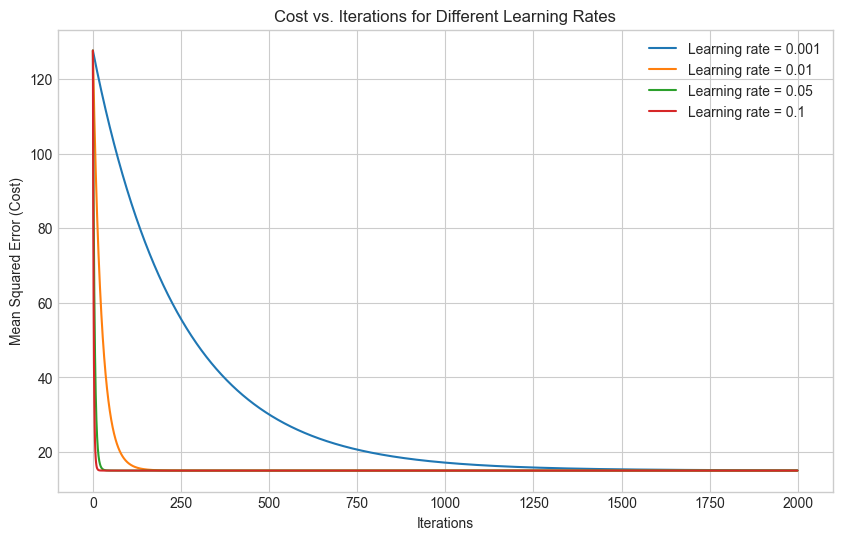

Final costs: {0.001: np.float64(15.000848603984311), 0.01: np.float64(14.938970947610972), 0.05: np.float64(14.938970943804087), 0.1: np.float64(14.938970943804087)}
Best learning rate based on final cost: 0.05


In [12]:
learning_rates = [0.001, 0.01, 0.05, 0.1]
models = {}

plt.figure(figsize=(10, 6))
for rate in learning_rates:
    model = LinearRegressionGD(learning_rate=rate, n_iterations=2000)
    model.fit(X_train_scaled, y_train)
    models[rate] = model
    plt.plot(model.cost_history, label=f'Learning rate = {rate}')

plt.title('Cost vs. Iterations for Different Learning Rates')
plt.xlabel('Iterations')
plt.ylabel('Mean Squared Error (Cost)')
plt.legend()
plt.show()

final_costs = {rate: model.cost_history[-1] for rate, model in models.items()}
best_rate = min(final_costs, key=final_costs.get)
print('Final costs:', final_costs)
print('Best learning rate based on final cost:', best_rate)

**Inference:** A good learning rate produces a smooth decrease in the cost value and reaches a lower loss in fewer iterations. A very small rate learns slowly. A very large rate may overshoot the minimum and make the cost unstable.

## 7. Train Final Model and Evaluate It

In [13]:
final_model = LinearRegressionGD(learning_rate=best_rate, n_iterations=3000)
final_model.fit(X_train_scaled, y_train)
y_pred = final_model.predict(X_test_scaled)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

results = pd.DataFrame({
    'Metric': ['MAE', 'MSE', 'RMSE', 'R² Score'],
    'Value': [mae, mse, rmse, r2]
})
display(results.round(4))

,Metric,Value
0,MAE,3.3953
1,MSE,17.6037
2,RMSE,4.1957
3,R² Score,0.1415


,Actual G3,Predicted G3
0,10,1.89
1,12,7.45
2,5,8.31
3,10,11.55
4,9,10.20
5,13,9.43
6,18,13.21
7,6,12.69
8,0,10.27
9,14,12.34


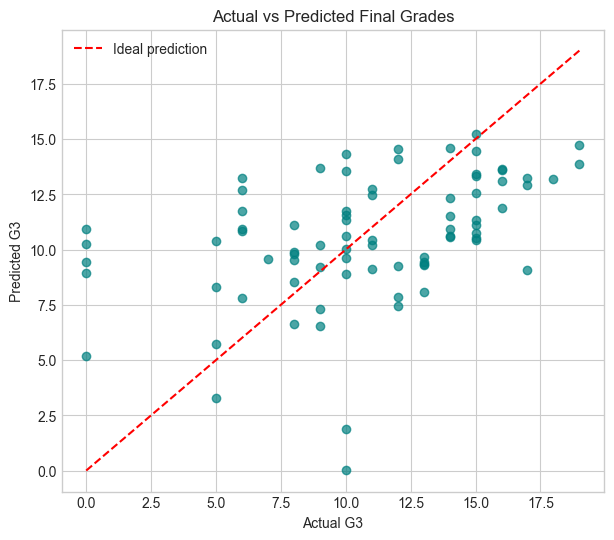

In [15]:
comparison = pd.DataFrame({
    'Actual G3': y_test.to_numpy(),
    'Predicted G3': y_pred
})
display(comparison.head(10).round(2))

plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred, alpha=0.7, color='teal')
limits = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
plt.plot(limits, limits, 'r--', label='Ideal prediction')
plt.title('Actual vs Predicted Final Grades')
plt.xlabel('Actual G3')
plt.ylabel('Predicted G3')
plt.legend()
plt.show()

## 8. Conclusion

**Inference:** The cost plot shows whether Gradient Descent has converged; the curve should become almost flat after enough iterations. Lower MAE and RMSE mean that predicted grades are closer to actual grades. A higher R² score means the model explains more variation in the final grades.

**Conclusion:** The model was trained successfully using Gradient Descent and tested on unseen data. The final metrics show its prediction quality. The learning-rate plot also helps in choosing a rate that gives stable convergence.